Model Accuracy: 80.72%


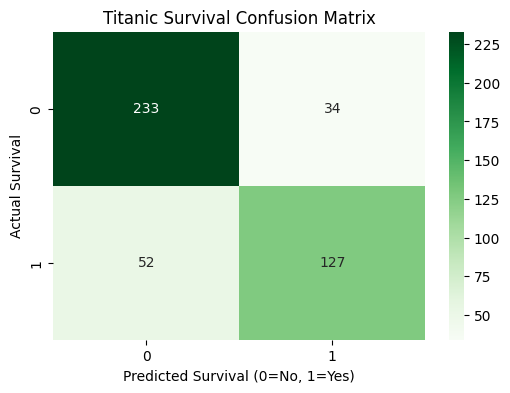


Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       267
           1       0.79      0.71      0.75       179

    accuracy                           0.81       446
   macro avg       0.80      0.79      0.80       446
weighted avg       0.81      0.81      0.81       446



In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
df = pd.read_csv('titanic.csv')
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1}) 
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True) 

X = df.drop('Survived', axis=1) 
y = df['Survived']          
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
model = LogisticRegression(max_iter=500) 
model.fit(X_train, y_train)
predictions = model.predict(X_test)
acc = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {acc * 100:.2f}%")

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Titanic Survival Confusion Matrix')
plt.xlabel('Predicted Survival (0=No, 1=Yes)')
plt.ylabel('Actual Survival')
plt.show()


print("\nDetailed Performance Report:")
print(classification_report(y_test, predictions))